In [152]:
import pandas as pd
import re
import string
from nltk.stem import WordNetLemmatizer
import nltk

nltk.download('wordnet')
nltk.download('omw-1.4')
lemmatizer = WordNetLemmatizer()

# read data
df1 = pd.read_csv("https://raw.githubusercontent.com/FNXNRNJOYCE/HKU/main/7005/guardian_abortion_articles_us.csv", encoding="utf-8-sig")

# look data
print("dataset row:", df.columns.tolist())
print("dataset first column:")
print(df.head())

# clean words
stop_words = set([
    'a', 'an', 'the', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by',
    'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did',
    'will', 'would', 'could', 'should', 'may', 'might', 'must', 'can',
    'i', 'you', 'he', 'she', 'it', 'we', 'they', 'me', 'him', 'her', 'us', 'them',
    'this', 'that', 'these', 'those', 'my', 'your', 'his', 'her', 'its', 'our', 'their',
    'from', 'as', 'so', 'than', 'too', 'very', 'just', 'now', 'then', 'here', 'there',
    'when', 'where', 'why', 'how', 'what', 'which', 'who', 'whom',
    'also', 'however', 'therefore', 'moreover', 'furthermore', 'nevertheless',
    'said', 'says', 'according', 'like', 'time', 'people', 'year', 'years', 'new','not','about','after','all','abortion'
])

def clean_text(text):
    """
    clean data
    """
    if pd.isna(text):
        return ""
    
    # trensform to str
    text = str(text)
    
    # 1. to lower words
    text = text.lower()
    
    # 2. discard the punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # 3. discard the numbers
    text = re.sub(r'\d+', '', text)
    
    # 4. split the word
    words = text.split()

    #5.
    lemmatized_words = []
    for word in words:
        lemma = lemmatizer.lemmatize(lemmatizer.lemmatize(word, pos='v'), pos='n')
        lemmatized_words.append(lemma)
    
    # 6. discard the stop words and less than 2
    filtered_words = [
        word for word in lemmatized_words  
        if word not in stop_words and len(word) > 2
    ]
    
    # 7. join the words together again
    cleaned_text = ' '.join(filtered_words)
    
    # 8. clean the space
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()
    
    return cleaned_text

#select the column that want to clean
text_column = 'text'  

# clean data 
print(f"ceaning data: {text_column}")
df['cleaned_text'] = df[text_column].apply(clean_text)

# save the clean data
output_path = "guardian_abortion_articles_us.csv"
df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"\n celan have save in: {output_path}")


# conpare the data
print("\n compare the data:")
print("=" * 50)
for i in range(min(3, len(df))):
    original_text = str(df[text_column].iloc[i])
    cleaned_text = df['cleaned_text'].iloc[i]
    
    print(f"sample {i+1} - the original sample:")
    print(original_text[:200] + "..." if len(original_text) > 200 else original_text)
    print(f"\nsample {i+1} - data cleaning after:")
    print(cleaned_text[:200] + "..." if len(cleaned_text) > 200 else cleaned_text)
    print("-" * 50)

# calcualte the information
original_avg_length = df[text_column].astype(str).apply(len).mean()
cleaned_avg_length = df['cleaned_text'].astype(str).apply(len).mean()


print(f"the original data lenth: {original_avg_length:.2f} ")
print(f"after: {cleaned_avg_length:.2f} ")
print(f"reduce: {((original_avg_length - cleaned_avg_length) / original_avg_length * 100):.2f}%")

[nltk_data] Downloading package wordnet to /Users/cyy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/cyy/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


dataset row: ['keyword', 'title', 'text', 'date', 'url', 'cleaned_text']
dataset first column:
    keyword                                              title  \
0  abortion  Anti-abortion groups furious as FDA approves g...   
1  abortion  What Tuesday’s elections mean for the future o...   
2  abortion  Wisconsin Planned Parenthood clinics suspend a...   
3  abortion  Belén review – gripping true story of woman un...   
4  abortion  SA attorney general refers anti-abortion activ...   

                                                text                  date  \
0  In a move that has left anti-abortion advocate...  2025-10-02T23:44:59Z   
1  Supporters of abortion rights have spent much ...  2025-11-06T12:00:56Z   
2  Planned Parenthood clinics in Wisconsin will s...  2025-10-01T18:54:52Z   
3  Belén is a pseudonym; in 2014, a 25-year-old w...  2025-11-05T07:00:18Z   
4  A “fun little game” launched by the anti-abort...  2025-11-13T14:00:44Z   

                                       

In [7]:
#make the pictures of mask
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


def create_guardian_mask():
    fig, ax = plt.subplots(figsize=(20, 8))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    ax.axis('off')
    

    ax.text(0.5, 0.5, 'GUARDIAN', 
            fontsize=160,
            fontweight='bold',
            ha='center', 
            va='center',
            color='black')
    
 
    plt.savefig('temp_guardian_mask.png', dpi=150, bbox_inches='tight', 
                facecolor='white', pad_inches=0)
    plt.close()
    
   
    mask = np.array(Image.open('temp_guardian_mask.png'))
    return mask
guardian_mask = create_guardian_mask()

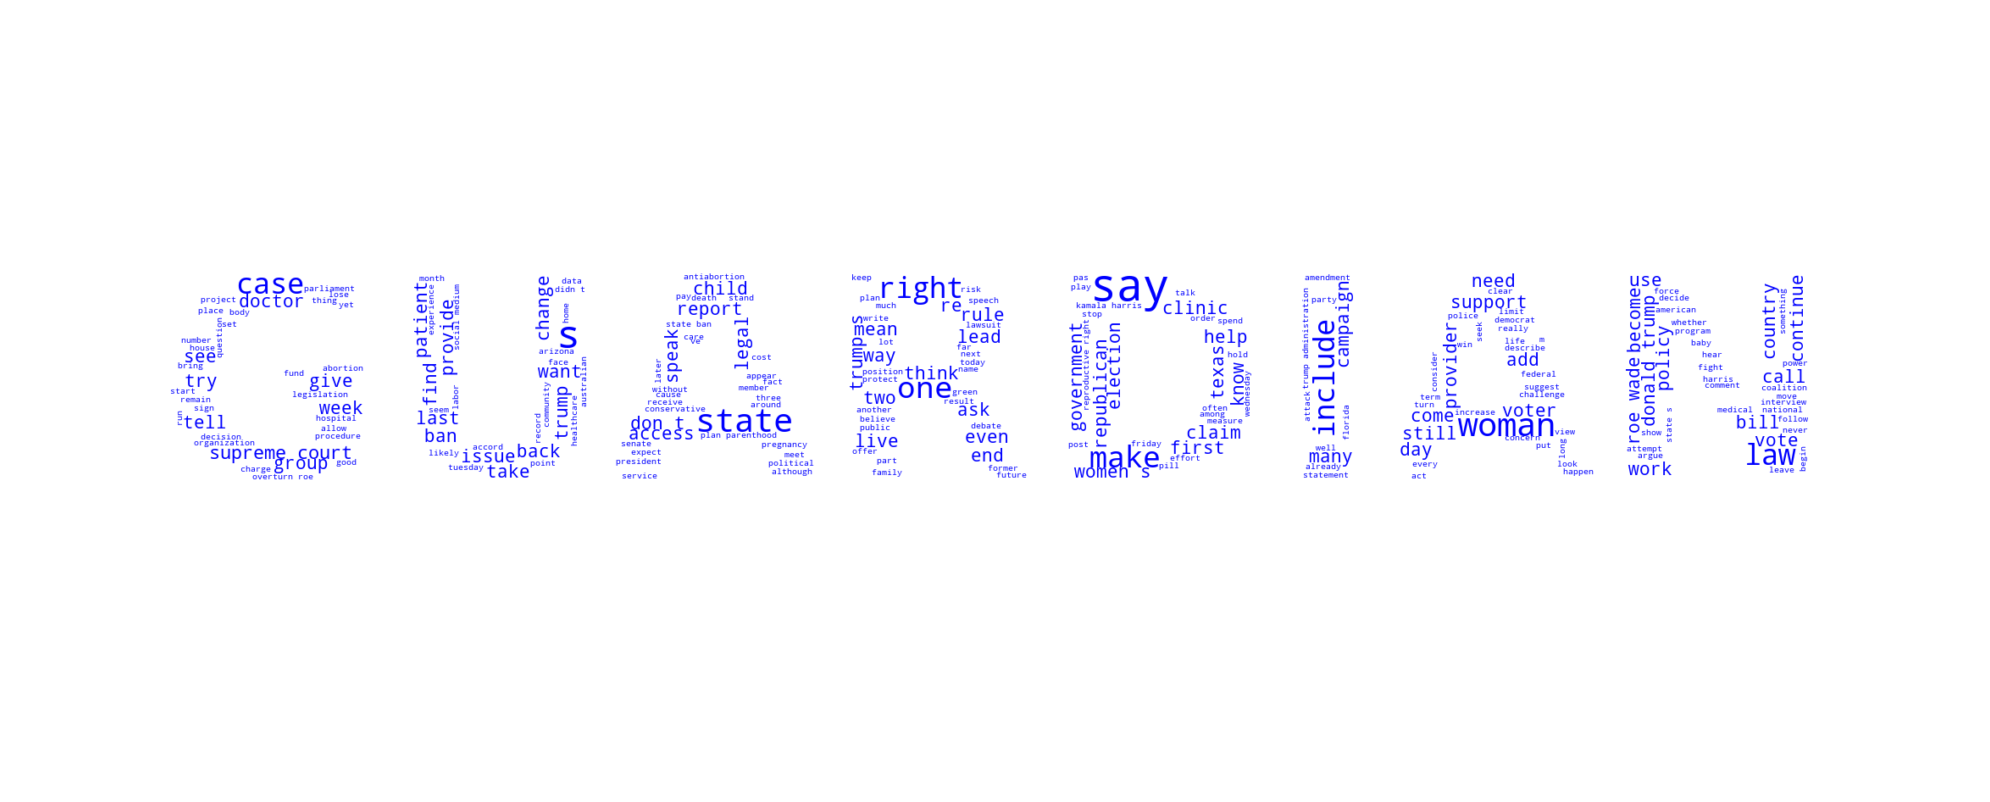

In [11]:
import pandas as pd

df_clean = pd.read_csv("https://raw.githubusercontent.com/FNXNRNJOYCE/HKU/main/7005/guardian_abortion_articles_us_clean.csv", encoding="utf-8")
guardian_text = ' '.join(df_clean['cleaned_text'].dropna())

def blue_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    return "blue"  

# blue color
def blue_colormap(word, font_size, position, orientation, random_state=None, **kwargs):
    if font_size > 80:
        return "#8B0000"  
    elif font_size > 40:
        return "#0000A0"  
    else:
        return "#0047AB"  


wordcloud_guardian = WordCloud(
    mask=guardian_mask,
    background_color='white',
    color_func=blue_color_func,   
    max_words=250,
    width=2000,
    height=1000,
    relative_scaling=0.3,
).generate(guardian_text)


plt.figure(figsize=(20, 10))
plt.imshow(wordcloud_guardian, interpolation='bilinear')
plt.axis('off')
plt.tight_layout()
plt.show()


wordcloud_guardian.to_file('guardian_text_wordcloud.png')



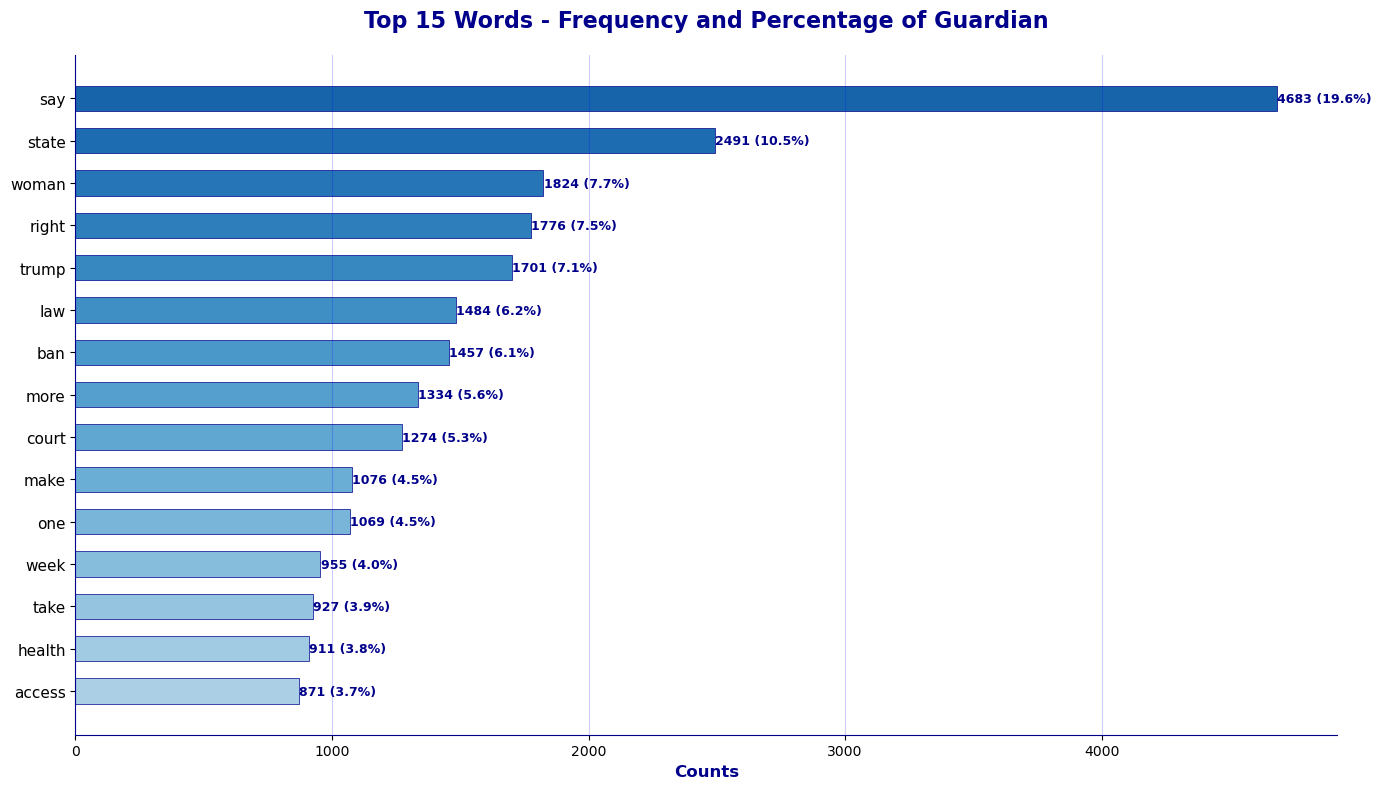

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# read data
df_clean = pd.read_csv("https://raw.githubusercontent.com/FNXNRNJOYCE/HKU/main/7005/guardian_abortion_articles_us_clean.csv", encoding="utf-8")

# cout
text = ' '.join(df_clean['cleaned_text'].dropna().astype(str))
words = text.split()
word_freq = Counter(words)
top_words = word_freq.most_common(15)

# calculate the perecntage
total_count = sum(count for word, count in top_words)
words, counts = zip(*top_words)
percentages = [count/total_count*100 for count in counts]

# create the graph
plt.figure(figsize=(14, 8))
colors = plt.cm.Blues([0.8 - i/(len(words)*2) for i in range(len(words))])

bars = plt.barh(range(len(words)), counts, color=colors, height=0.6, 
                edgecolor='darkblue', linewidth=0.5)

plt.yticks(range(len(words)), words, fontsize=11)
plt.gca().invert_yaxis()
plt.xlabel('Counts', fontsize=12, fontweight='bold', color='darkblue')
plt.title('Top 15 Words - Frequency and Percentage of Guardian', fontsize=16, fontweight='bold', 
          pad=20, color='darkblue')

# show the perentage
for i, (count, percentage) in enumerate(zip(counts, percentages)):
    plt.text(count + 0.5, i, f'{count} ({percentage:.1f}%)', va='center', 
             fontsize=9, fontweight='bold', color='darkblue')

plt.grid(axis='x', alpha=0.2, color='blue')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('darkblue')
plt.gca().spines['bottom'].set_color('darkblue')

plt.tight_layout()
plt.savefig("guardian_word_freq_percent_combo.png", dpi=300, bbox_inches='tight')

plt.show()